To run nebula scirbt you need the follwing libraries:

```R
    library(glue)
    library(dplyr)
    library(getopt)
    library(Matrix)
    library(qs)
    library(Seurat)
    library(nebula)
    library(future)
```

```R
install.packages("getopt")

if (!require("devtools")) install.packages("devtools")
devtools::install_github("lhe17/nebula")

if (!require("BiocManager")) install.packages("BiocManager")
BiocManager::install("biomaRt")

```

R scritp from [link](https://github.com/bdferris642/sc-online/tree/main/scripts)

# Hyperparameters

In [1]:
%load_ext autoreload
%autoreload 2



import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro

from dotenv import load_dotenv; load_dotenv()


from utils import preprocessing
from utils import DEG

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

GRADIENT_GENES_CORR_PATH = os.getenv("GRADIENT_GENES_CORR_PATH")
PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")


ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1.0_raw.h5ad"
adata_path_name=f"{os.path.split(ADATA_PATH)[1].split('.')[0]}"
ADATA_PATH_BASE = os.path.splitext(ADATA_PATH)[0]
ADATA_FOLDER = os.path.dirname(ADATA_PATH)
SAVE_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/artificial_DEG_analysis/dorsal-ventral-score/{adata_path_name}"
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results
TRUE_DEG_PATH = f"{ADATA_FOLDER}/genes.csv"
os.makedirs(SAVE_FOLDER, exist_ok=True)

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "spn_type" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "case_control"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "case"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic",
                      "gradient_score" # --> SPEICFIC FOR THIS ANALSYSIS
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "nCount_RNA"

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
LOGFC_THR=0.1
PVAL_THR=0.05

# Read adata

In [2]:
adata = sc.read_h5ad(
    #"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/NucSeq_all_labelled_zoned.h5ad", 
    ADATA_PATH,
    backed="r"
    )

#adata = adata[adata.obs.spn_type == "dorsal_matrix"][:50000].copy()


adata

AnnData object with n_obs × n_vars = 191639 × 37905 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1.0_raw.h5ad'
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'x', 'y', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'cb', 'Final_Zone_Assignments', 'Group_name.1', 'cell_type', 'Cohort', 'Biobank', 'Age.at.Death', 'Sex', 'Race', 'Ethnicity', 'Ca

In [ ]:
# adata_c = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/diseased/sample_01/adata/all_lib_adata_zoned.h5ad")
# adata_c.var_names = adata_c.var.gene_symbol.astype(str)
# adata_c.var_names_make_unique() 

# Calculate gradient-score

Specific for cell type (all samples together).

In [3]:
def compute_gradient_score(adata, gradient_csv_path, 
                          p_threshold=0.05,
                          corr_threshold=None, 
                          use_layer=None,
                          standardize=True):
    """
    Compute dorsal-ventral gradient scores.
    
    Parameters:
    -----------
    adata : AnnData
        Single-cell data
    gradient_csv_path : str
        Path to gradient gene CSV
    p_threshold : float
        P-value threshold (default: 0.05)
    corr_threshold : float, optional
        Minimum absolute correlation (e.g., 0.1)
    use_layer : str or None
        'raw', 'counts', or None for adata.X
    standardize : bool
        Z-score normalize genes (recommended: True)
    
    Returns:
    --------
    dict with gradient_score, dorsal_score, ventral_score
    """
    # Load and filter gradient data
    gradient_df = pd.read_csv(gradient_csv_path)
    gradient_df = gradient_df[gradient_df['combined_p'] < p_threshold]
    
    if corr_threshold:
        gradient_df = gradient_df[np.abs(gradient_df['mean_spearman']) >= corr_threshold]
    
    gradient_df = gradient_df[gradient_df['gene'].isin(adata.var_names)]
    
    # Split dorsal/ventral
    dorsal_df = gradient_df[gradient_df['mean_spearman'] > 0]
    ventral_df = gradient_df[gradient_df['mean_spearman'] < 0]
    
    print(f"Using {len(gradient_df)} genes (p<{p_threshold}): "
          f"{len(dorsal_df)} dorsal, {len(ventral_df)} ventral")
    
    # Get expression matrix
    if use_layer == 'raw':
        X = adata.raw.X if adata.raw else adata.X
        var_names = adata.raw.var_names if adata.raw else adata.var_names
    elif use_layer:
        X = adata.layers[use_layer]
        var_names = adata.var_names
    else:
        X = adata.X
        var_names = adata.var_names
    
    # Helper function to compute score
    def compute_score(df, negate=False):
        if len(df) == 0:
            return np.zeros(X.shape[0])
        
        idx = [list(var_names).index(g) for g in df['gene']]
        X_sub = X[:, idx]
        
        if sparse.issparse(X_sub):
            X_sub = X_sub.toarray()
        
        if standardize:
            means = X_sub.mean(axis=0)
            stds = X_sub.std(axis=0)
            stds[stds == 0] = 1
            X_sub = (X_sub - means) / stds
        
        weights = df['mean_spearman'].values
        score = X_sub @ weights
        
        return -score if negate else score
    
    # Compute scores
    gradient_scores = compute_score(gradient_df)
    dorsal_scores = compute_score(dorsal_df)
    ventral_scores = compute_score(ventral_df, negate=True)
    
    # Store in adata
    adata.obs['gradient_score'] = gradient_scores
    adata.obs['dorsalness'] = gradient_scores
    adata.obs['dorsal_score'] = dorsal_scores
    adata.obs['ventral_score'] = ventral_scores
    
    return {
        'gradient_score': gradient_scores,
        'dorsal_score': dorsal_scores,
        'ventral_score': ventral_scores
    }


In [4]:
# Initialize X_umap if it doesn't exist
if 'X_umap' not in adata.obsm:
    adata.obsm['X_umap'] = np.full((adata.shape[0], 2), np.nan)

for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

    a = adata[adata.obs[CT_FOR_DEG_VARIABLE] == ct].copy()

    print(ct,"\n", a)

    #############################
    # Save counts

    if "counts" in a.layers:
        print("Putting raw counts in .X")
        a.X = a.layers["counts"].copy()
    else:
        a.layers["counts"] = a.X.copy()
        print("Be sure that .X is raw counts")

    #############################
    # Compute gradients
    scores = compute_gradient_score(
        a,
        GRADIENT_GENES_CORR_PATH,
        use_layer="counts",
        standardize=True,
        p_threshold=0.05,
        corr_threshold=0.1
    )

    # SAVE BACK to original adata (only for these cells)
    adata.obs.loc[a.obs_names, 'gradient_score'] = a.obs['gradient_score']
    adata.obs.loc[a.obs_names, 'dorsal_score'] = a.obs['dorsal_score']
    adata.obs.loc[a.obs_names, 'ventral_score'] = a.obs['ventral_score']

    #############################
    # Save qs

    print("\tSaving files for R coversion...")
    preprocessing.save_files_for_R_conversion(a, QS_TMP_FOLDER)
    print("\tBuilding R obj...")
    saving_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}.qs")
    preprocessing.build_qs_from_python_files(QS_TMP_FOLDER, saving_path=saving_path, contrast_var=CONTRAST_VARIABLE, reference_level=CONTRAST_BASELINE)

    PLOTTING_UMAP = False
    if PLOTTING_UMAP:

        #############################À
        # Compute umap

        print("Processing...")
        preprocessing.preprocess(a, save_raw_counts=(not("counts" in a.layers)))
        #a.obs["Final_Zone_Assignments"] = a.obs["Final_Zone_Assignments"].astype("category")

        # remoc .X useless
        import scipy.sparse as sp
        a.X = sp.csr_matrix(a.shape)

        # SAVE BACK to original adata (only for these cells)
        cell_indices = [adata.obs_names.get_loc(cell) for cell in a.obs_names]
        adata.obsm['X_umap'][cell_indices, :] = a.obsm['X_umap']

        #############################À
        # Plot umap

        # Plot
        sc.pl.embedding(a, basis="X_umap", color=['gradient_score', 'dorsal_score', 'ventral_score'] , cmap='RdBu_r')# vmin=-100, vmax=100)
        sc.pl.embedding(a, basis="X_umap", color=[SAMPLE_VARIABLE, CONTRAST_VARIABLE, *COVARIATES_FOR_DEG, ])# vmin=-100, vmax=100)

        # Histograms
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for ax, col, color, title in zip(axes, 
                                        ['gradient_score', 'dorsal_score', 'ventral_score'],
                                        ['purple', 'red', 'blue'],
                                        ['Combined', 'Dorsal', 'Ventral']):
            ax.hist(a.obs[col], bins=100, color=color, alpha=0.7)
            ax.set_xlabel(f'{title} Score')
            ax.axvline(0, color='black', linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

        # only if it has spatial:
        if "spatial" in adata.obsm:
            sc.pl.embedding(a, basis="spatial", color=["gradient_score", "ventral_score", "dorsal_score"])

    #break

ventral_matrix 
 AnnData object with n_obs × n_vars = 48688 × 37905
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'x', 'y', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'cb', 'Final_Zone_Assignments', 'Group_name.1', 'cell_type', 'Cohort', 'Biobank', 'Age.at.Death', 'Sex', 'Race', 'Ethnicity', 'Cause.of.Death', 'PMI', 'spn_type', 'case_control', 'RNA_snn_res.0.2', 'seurat_clusters', 'RNA_snn_res.0.5', 'Row.names', 'PC_1', 'PC_2', 'PC_3', 'P

2026-01-29 19:42:34 | [WARNING] R callback write-console: Loading required package: SeuratObject
  
2026-01-29 19:42:34 | [WARNING] R callback write-console: Loading required package: sp
  
2026-01-29 19:42:35 | [WARNING] R callback write-console: 
Attaching package: ‘SeuratObject’

  
2026-01-29 19:42:35 | [WARNING] R callback write-console: The following objects are masked from ‘package:base’:

    %||%, intersect, t

  



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

2026-01-29 19:42:38 | [WARNING] R callback write-console: 
Attaching package: ‘Seurat’

  
2026-01-29 19:42:38 | [WARNING] R callback write-console: The following object is masked from ‘package:base’:

    %||%

  
2026-01-29 19:42:38 | [WARNING] R callback write-console: qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103
  



Setting case_control reference level to: control
Levels: control case 


...

2026-01-29 19:52:39 | [WARNING] R callback write-console: Warning:  
2026-01-29 19:52:39 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


espn 
 AnnData object with n_obs × n_vars = 31973 × 37905
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'x', 'y', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'cb', 'Final_Zone_Assignments', 'Group_name.1', 'cell_type', 'Cohort', 'Biobank', 'Age.at.Death', 'Sex', 'Race', 'Ethnicity', 'Cause.of.Death', 'PMI', 'spn_type', 'case_control', 'RNA_snn_res.0.2', 'seurat_clusters', 'RNA_snn_res.0.5', 'Row.names', 'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_

2026-01-29 19:56:32 | [WARNING] R callback write-console: Warning:  
2026-01-29 19:56:32 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


patch 
 AnnData object with n_obs × n_vars = 38033 × 37905
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'x', 'y', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'cb', 'Final_Zone_Assignments', 'Group_name.1', 'cell_type', 'Cohort', 'Biobank', 'Age.at.Death', 'Sex', 'Race', 'Ethnicity', 'Cause.of.Death', 'PMI', 'spn_type', 'case_control', 'RNA_snn_res.0.2', 'seurat_clusters', 'RNA_snn_res.0.5', 'Row.names', 'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC

2026-01-29 20:00:13 | [WARNING] R callback write-console: Warning:  
2026-01-29 20:00:13 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


# DEG

In [ ]:
# adata = sc.read_h5ad(
#     #"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/NucSeq_all_labelled_zoned.h5ad", 
#     "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1.0_raw.h5ad",
#     backed="r"
#     )

In [6]:
for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

    ct="patch"

    print(ct,"\n")

    # Run Nebula
    nebula_result_path = DEG.run_nebula_parallel_script(
        path_qs = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}.qs"),
        path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
        id_col = SAMPLE_VARIABLE,
        covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG], # wihtout LIBRARY_SIZE_COL, with constrst vaibale too
        offset_col = LIBRARY_SIZE_COL,
        n_folds = 8,
        n_cores = 16,
        save_tmp = False,
        suffix = None,
    )

    # save csv
    csv_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_nebula_results.csv")
    ro.r(f'''
        library(qs)
        obj <- qread("{nebula_result_path}")
        df <- obj$summary
        write.csv(df, "{csv_path}", row.names = FALSE)
    ''')

    break
    

patch 

Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/artificial_DEG_analysis/dorsal-ventral-score/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1/patch.qs --id-col donor_id --offset-col nCount_RNA --n-folds 8 --n-cores 16 --save-tmp 0 --covs case_control,Age.at.Death,Sex,PMI,pct_mt,pct_intronic,gradient_score
STDOUT:
[INFO] Input: /home/gdallagl/myworkdir/XDP/data/artificial_DEG_analysis/dorsal-ventral-score/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1/patch.qs
[INFO] Script dir: /home/gdallagl/myworkdir/XDP/utils/nebula_scripts
[INFO] Base name: patch.qs
[INFO] Geneset dir: /home/gdallagl/myworkdir/data/artificial_DEG_analysis/dorsal-ventral-score/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1
[INFO] Geneset: zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1
[INFO] Split dir: /home/gdallagl/myworkdi

# Plot Results

In [4]:
df_true_degs = pd.read_csv(TRUE_DEG_PATH)
df_true_degs


,gene_id,log2fc,frac_applied,n_subjects_applied,subjects_applied
0,ENSG00000237280,0.522222,0.3,3,"MD9129,MS986638,UMBEB23076"
1,ENSG00000250027,0.733333,0.7,7,"MD9129,MS30499,MS706984,MS876075,MS986638,UMBE..."
2,ENSG00000289321,-0.733333,0.4,4,"MD6927,MS30499,MS876075,MS986638"
3,OTULIN,0.100000,0.6,6,"MD6927,MD9129,MS30499,MS876075,MS986638,UMBEB2..."
4,MYLIP,-0.522222,0.2,2,"MD6927,UMBEB22074"
...,...,...,...,...,...
395,FLVCR2,0.733333,0.1,1,UMBEB23158
396,PTPN20,1.577778,0.5,5,"MD6927,MS30499,MS706984,UMBEB22074,UMBEB23158"
397,RACGAP1,-0.100000,0.7,7,"MD6927,MD9129,MS30499,UMBEB22074,UMBEB23076,UM..."
398,ENSG00000257239,2.000000,0.5,5,"MS706984,MS876075,MS986638,UMBEB23076,UMBEB24013"



#################
ventral_matrix
#################



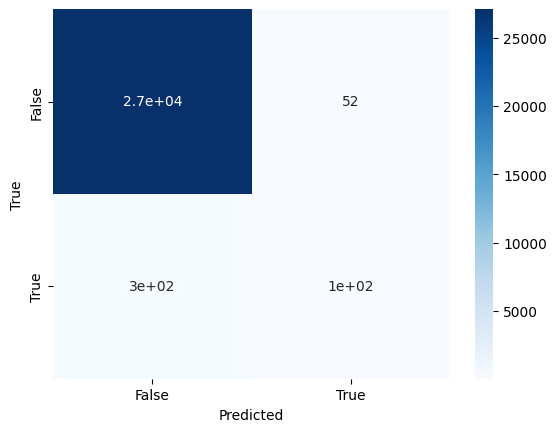

Precision: 0.658
Recall:    0.251
F1 Score:  0.363
Accuracy:  0.987
Clipping 14 genes with -log10(p) > 10


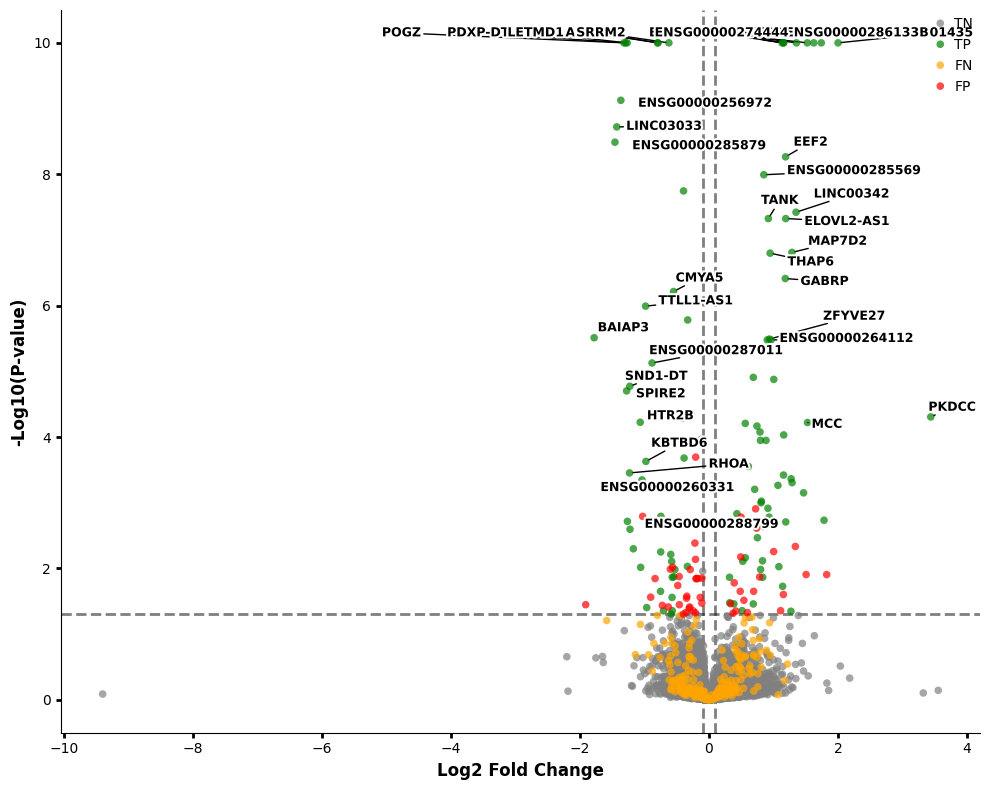

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.074118,0.171702,0.785220,False,False,0.105009,TN,-0.007783
1,A1BG-AS1,-0.062690,0.238337,0.820915,False,False,0.085702,TN,-0.005373
2,A1CF,-0.200797,0.099425,0.716977,False,False,0.144495,TN,-0.029014
3,A2M,0.291139,0.135753,0.757702,False,False,0.120501,TN,0.035083
4,A2M-AS1,0.037125,0.577958,0.924243,False,False,0.034214,TN,0.001270
...,...,...,...,...,...,...,...,...,...
27538,ZZEF1,-0.013486,0.621963,0.932995,False,False,0.030121,TN,-0.000406
27539,ZZZ3,0.036144,0.484449,0.902542,False,False,0.044532,TN,0.001610
27540,ENSG00000205653,0.167802,0.796655,0.966762,False,False,0.014680,TN,0.002463
27541,ENSG00000223438,0.268900,0.632085,0.935620,False,False,0.028901,TN,0.007771



#################
dorsal_matrix
#################



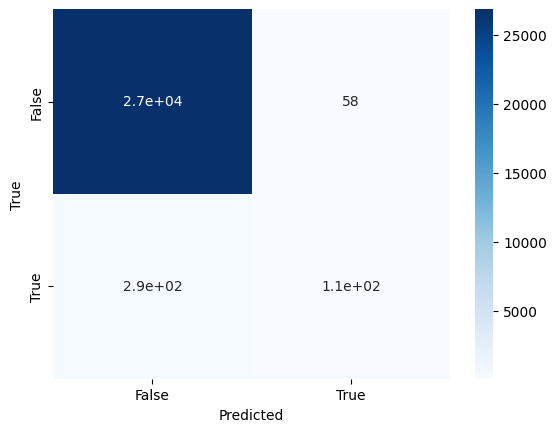

Precision: 0.646
Recall:    0.265
F1 Score:  0.376
Accuracy:  0.987
Clipping 15 genes with -log10(p) > 10


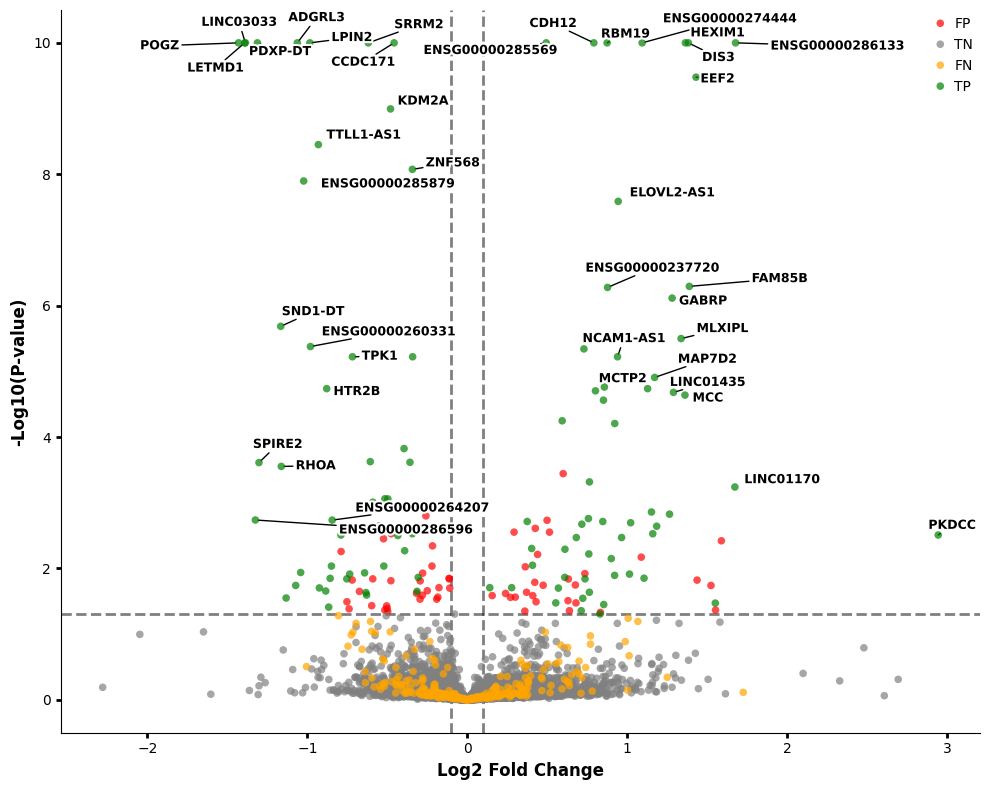

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.183638,0.000138,0.027306,True,False,1.563743,FP,-0.287163
1,A1BG-AS1,-0.041500,0.464718,0.896652,False,False,0.047376,TN,-0.001966
2,A1CF,-0.326385,0.002652,0.241381,False,False,0.617298,TN,-0.201477
3,A2M,0.231409,0.198097,0.827785,False,False,0.082083,TN,0.018995
4,A2M-AS1,0.045054,0.473462,0.897976,False,False,0.046735,TN,0.002106
...,...,...,...,...,...,...,...,...,...
27314,ZZEF1,-0.048073,0.084349,0.752632,False,False,0.123417,TN,-0.005933
27315,ZZZ3,0.006815,0.916880,0.987007,False,False,0.005680,TN,0.000039
27316,ENSG00000205653,0.516017,0.422843,0.885219,False,False,0.052949,TN,0.027323
27317,ENSG00000223438,-0.110867,0.866066,0.977244,False,False,0.009997,TN,-0.001108



#################
espn
#################



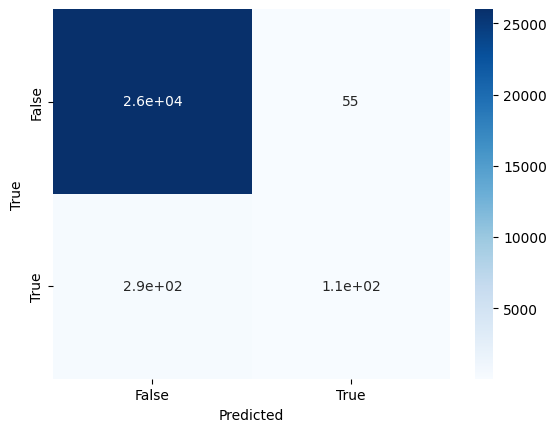

Precision: 0.667
Recall:    0.275
F1 Score:  0.389
Accuracy:  0.987
Clipping 24 genes with -log10(p) > 10


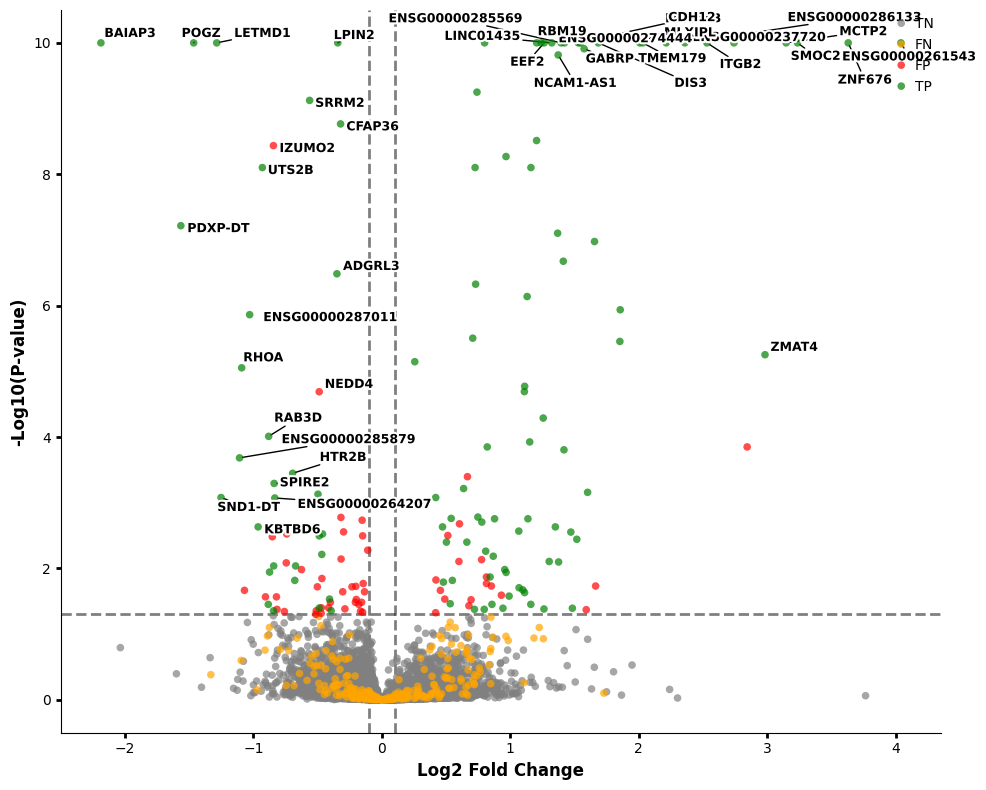

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.094929,0.292339,0.897330,False,False,0.047048,TN,-0.004466
1,A1BG-AS1,-0.103560,0.176259,0.832820,False,False,0.079449,TN,-0.008228
2,A1CF,-0.228541,0.302796,0.898909,False,False,0.046284,TN,-0.010578
3,A2M,0.108291,0.856455,0.987127,False,False,0.005627,TN,0.000609
4,A2M-AS1,0.017345,0.729826,0.976422,False,False,0.010362,TN,0.000180
...,...,...,...,...,...,...,...,...,...
26457,ZYX,0.015040,0.810315,0.984069,False,False,0.006974,TN,0.000105
26458,ZZEF1,-0.035080,0.188603,0.839019,False,False,0.076228,TN,-0.002674
26459,ZZZ3,0.006883,0.902928,0.993041,False,False,0.003033,TN,0.000021
26460,ENSG00000223438,-0.423673,0.472614,0.941040,False,False,0.026392,TN,-0.011182



#################
patch
#################



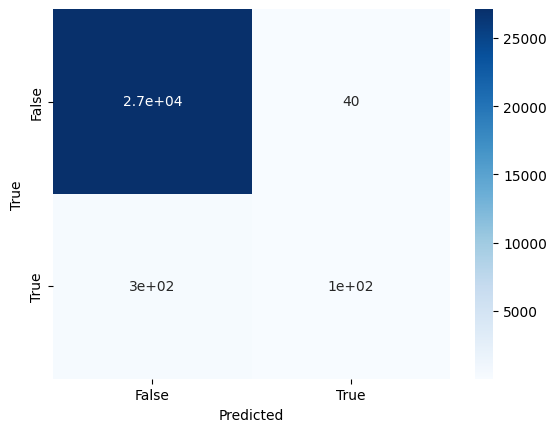

Precision: 0.716
Recall:    0.253
F1 Score:  0.373
Accuracy:  0.988
Clipping 16 genes with -log10(p) > 10


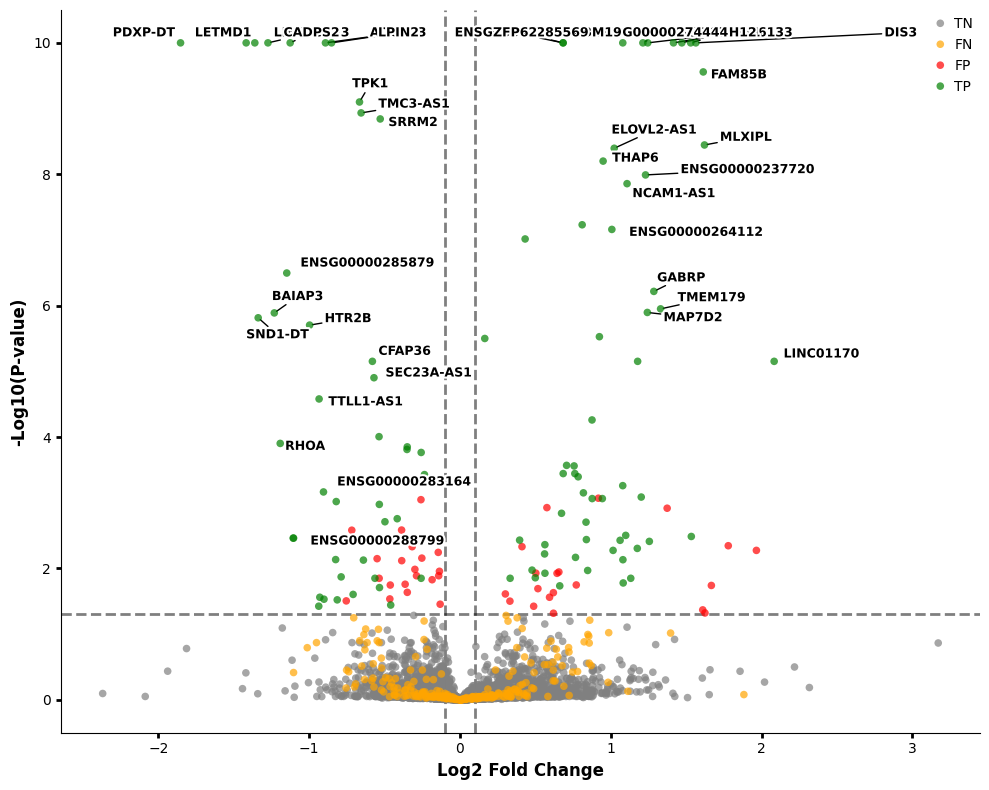

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.106011,0.025142,0.659502,False,False,0.180784,TN,-0.019165
1,A1BG-AS1,-0.044394,0.460071,0.918188,False,False,0.037068,TN,-0.001646
2,A1CF,-0.319644,0.012846,0.525881,False,False,0.279113,TN,-0.089217
3,A2M,0.198005,0.466941,0.918941,False,False,0.036712,TN,0.007269
4,A2M-AS1,0.005276,0.936839,0.991747,False,False,0.003599,TN,0.000019
...,...,...,...,...,...,...,...,...,...
27546,ZZEF1,-0.055851,0.050321,0.756060,False,False,0.121444,TN,-0.006783
27547,ZZZ3,0.013019,0.851347,0.977384,False,False,0.009935,TN,0.000129
27548,ENSG00000205653,0.115473,0.845305,0.976698,False,False,0.010240,TN,0.001182
27549,ENSG00000223438,0.361039,0.607528,0.941031,False,False,0.026396,TN,0.009530


In [7]:
for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

    #ct="dorsal_matrix"

    print(f"\n#################\n{ct}\n#################\n")

    csv_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_nebula_results.csv")

    df_nebula = pd.read_csv(csv_path)

    DEG.plot_nebula_results(df_nebula, 
                        df_true_degs, 
                        col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                        col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                        col_gene="gene",
                        PVAL_THR=PVAL_THR,
                        LOGFC_THR=LOGFC_THR,
                        max_FDR=10,
                        add_adj_p_col=True
                        )
    #break

# Over All Plot

ventral_matrix
dorsal_matrix
espn
patch


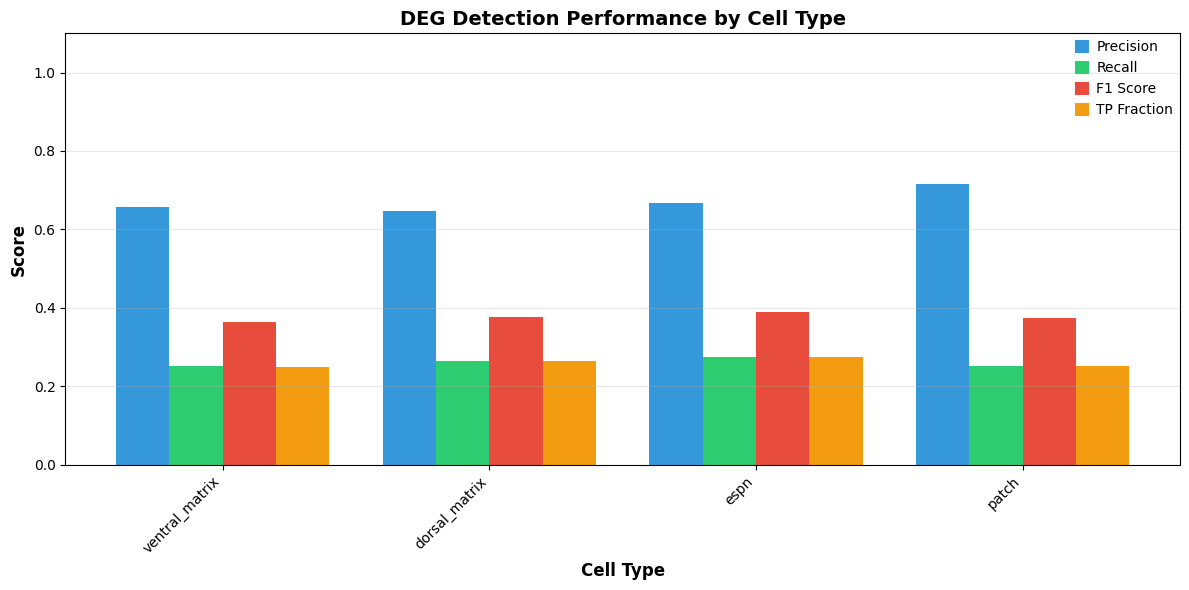


Metrics Summary:
     Cell Type  Precision   Recall       F1  TP Fraction
ventral_matrix   0.657895 0.250627 0.362976       0.2500
 dorsal_matrix   0.646341 0.265000 0.375887       0.2650
          espn   0.666667 0.275000 0.389381       0.2750
         patch   0.716312 0.252500 0.373383       0.2525


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Collect metrics for all cell types
results = []

for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

    print(ct)
    
    # Read CSV
    csv_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_nebula_results.csv")
    df_nebula = pd.read_csv(csv_path)
        
    # Calculate adjusted p-values
    from statsmodels.stats.multitest import multipletests
    col_p_adj = f"adj_p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
    df_nebula[col_p_adj] = multipletests(df_nebula[f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"], method="fdr_bh")[1]
    
    # Determine significance
    df_nebula["is_significant"] = (
        (df_nebula[col_p_adj] <= PVAL_THR) & 
        (np.abs(df_nebula[f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"]) >= LOGFC_THR)
    )
    df_nebula["is_true_DEG"] = df_nebula["gene"].isin(df_true_degs["gene_id"])
    
    # Calculate metrics
    precision = precision_score(df_nebula["is_true_DEG"], df_nebula["is_significant"])
    recall = recall_score(df_nebula["is_true_DEG"], df_nebula["is_significant"])
    f1 = f1_score(df_nebula["is_true_DEG"], df_nebula["is_significant"])
    
    # TP fraction
    tp = (df_nebula["is_true_DEG"] & df_nebula["is_significant"]).sum()
    tp_fraction = tp / df_true_degs.shape[0]
    
    results.append({
        'Cell Type': ct,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'TP Fraction': tp_fraction
    })

    #break

# Create dataframe
df_metrics = pd.DataFrame(results)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_metrics))
width = 0.2

ax.bar(x - 1.5*width, df_metrics['Precision'], width, label='Precision', color='#3498db')
ax.bar(x - 0.5*width, df_metrics['Recall'], width, label='Recall', color='#2ecc71')
ax.bar(x + 0.5*width, df_metrics['F1'], width, label='F1 Score', color='#e74c3c')
ax.bar(x + 1.5*width, df_metrics['TP Fraction'], width, label='TP Fraction', color='#f39c12')

ax.set_xlabel('Cell Type', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('DEG Detection Performance by Cell Type', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_metrics['Cell Type'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Display table
print("\nMetrics Summary:")
print(df_metrics.to_string(index=False))



---
---
---

In [ ]:
# for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

#     path_qs = f"{QS_TMP_FOLDER}/{ct.replace(' ', '_')}.qs"
#     output_csv = f"{QS_TMP_FOLDER}/{ct.replace(' ', '_')}_nebula_results.csv"

#     print(ct, "\n", path_qs, "\n", output_csv)
    
#     import rpy2.robjects as ro

#     ro.r(f"""
#         library(nebula)
#         library(qs)
#         library(Seurat)
        
#         # Load Seurat object
#         cat("Loading", "{ct}", "...\\n")
#         sobj <- qread("{path_qs}")
        
#         # Extract count matrix (genes x cells) - Seurat v5
#         count_matrix <- GetAssayData(sobj, assay = "RNA", layer = "counts")
#         #count_matrix <- as.matrix(count_matrix)

#         # ========== CRITICAL: FILTER GENES FIRST ==========
#         # Remove genes with very low expression
#         genes_total_counts <- Matrix::rowSums(count_matrix)
#         genes_n_cells <- Matrix::rowSums(count_matrix > 0)
        
#         # Keep only genes with:
#             # - At least 50 cells expressing
#             # - At least 100 total counts across all cells
#         keep_genes <- (genes_n_cells >= 50) & (genes_total_counts >= 100)
#         cat("Genes before filtering:", nrow(count_matrix), "\\n")
#         count_matrix <- count_matrix[keep_genes, ]
#         cat("Genes after filtering:", nrow(count_matrix), "\\n")
        
        
#         # Extract metadata
#         meta <- sobj@meta.data
        
#         # CRITICAL: Ensure factors are properly coded
#         # Convert condition to factor if it isn't already
#         meta${CONTRAST_VARIABLE} <- as.factor(meta${CONTRAST_VARIABLE})
        
#         # Get ID vector (must be factor for NEBULA)
#         id <- as.factor(meta[["{SAMPLE_VARIABLE}"]])
        
#         # Get offset (library size)
#         offset <- meta[["{LIBRARY_SIZE_COL}"]]
        
#         cat("\\nData dimensions:\\n")
#         cat("  Genes:", nrow(count_matrix), "\\n")
#         cat("  Cells:", ncol(count_matrix), "\\n")
#         cat("  Subjects:", length(unique(id)), "\\n")
#         cat("  Condition levels:", levels(meta${CONTRAST_VARIABLE}), "\\n")
        
#         # Build DESIGN MATRIX (not just data frame!)
#         # NEBULA needs model.matrix format with intercept
#         pred_formula <- as.formula("~ {' + '.join([CONTRAST_VARIABLE, *COVARIATES_FOR_DEG])}")
#         pred_matrix <- model.matrix(pred_formula, data = meta)
        
#         cat("\\nPredictor matrix dimensions:", dim(pred_matrix), "\\n")
#         cat("Predictor columns:", colnames(pred_matrix), "\\n")
        
#         # Group cells by subject (recommended for speed and accuracy)
#         # Try to group (reorder) cells by subject
#         data_g <- group_cell(
#             count = count_matrix,
#             id = id,
#             pred = pred_matrix,
#             offset = offset
#         )
        
#         # If NULL, cells already sorted - use original data
#         if (is.null(data_g)) {{
#             cat("Cells already sorted by subject - using original data\\n")
#             data_g <- list(
#                 count = count_matrix,
#                 id = id,
#                 pred = pred_matrix,
#                 offset = offset
#             )
#         }}
                
#         # Run NEBULA with LN method (log-normal)
#         cat("\\nRunning NEBULA LN method...\\n")
#         re <- nebula(
#             count = data_g$count,
#             id = data_g$id,
#             pred = data_g$pred,
#             offset = data_g$offset,
#             method = 'LN', # HL more accurate
#             ncore = 4
#         )
        
#         cat("\\nNEBULA completed!\\n")
        
#         # Extract summary
#         summary_df <- re$summary
        
#         cat("Result columns:", colnames(summary_df), "\\n")
#         cat("Number of genes tested:", nrow(summary_df), "\\n")
        
#         # Save full results
#         write.csv(summary_df, "{output_csv}", row.names = FALSE, quote = FALSE)
#         cat("Saved results to {output_csv}\\n")
        
#         # Print summary statistics
#         if ("{CONTRAST_VARIABLE}" %in% colnames(summary_df)) {{
#             sig_genes <- sum(summary_df$p_{CONTRAST_VARIABLE} < 0.05, na.rm = TRUE)
#             cat("Significant genes (p < 0.05):", sig_genes, "\\n")
#         }}

#         rm(sobj, count_matrix, meta, data_g, re)
#         gc()
#     """)
    
#     print(f"✓ Completed {ct}\n")
    
#     break